Image loaded successfully.
Image size: (892, 807)


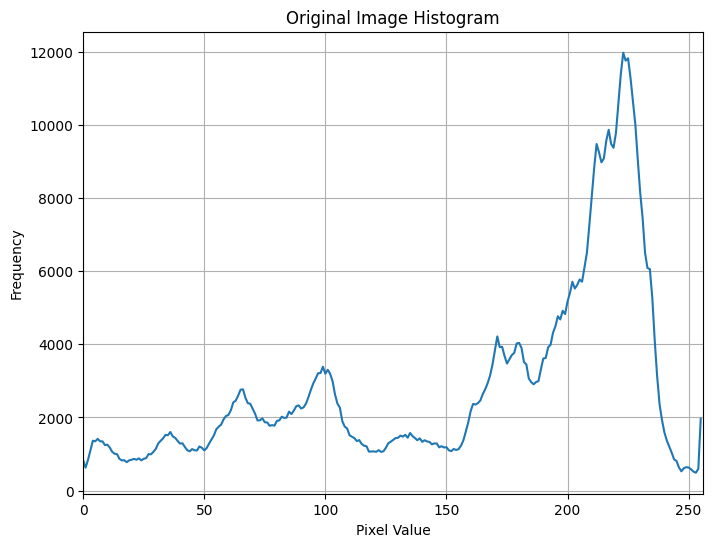

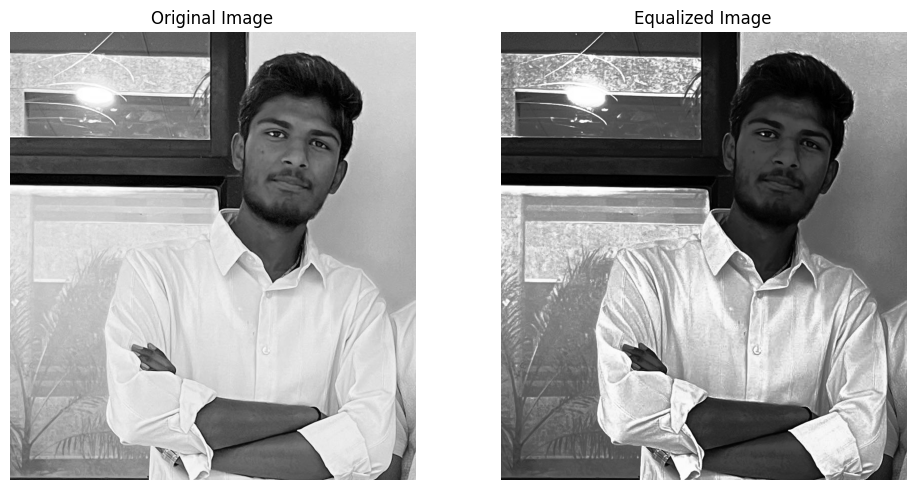

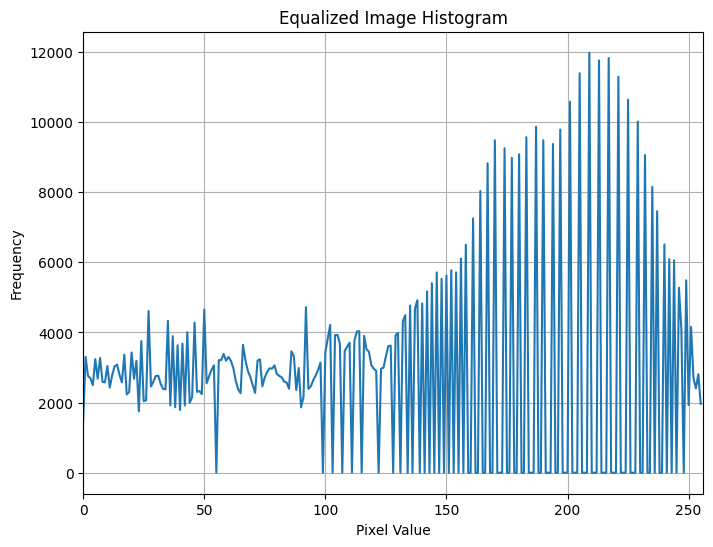

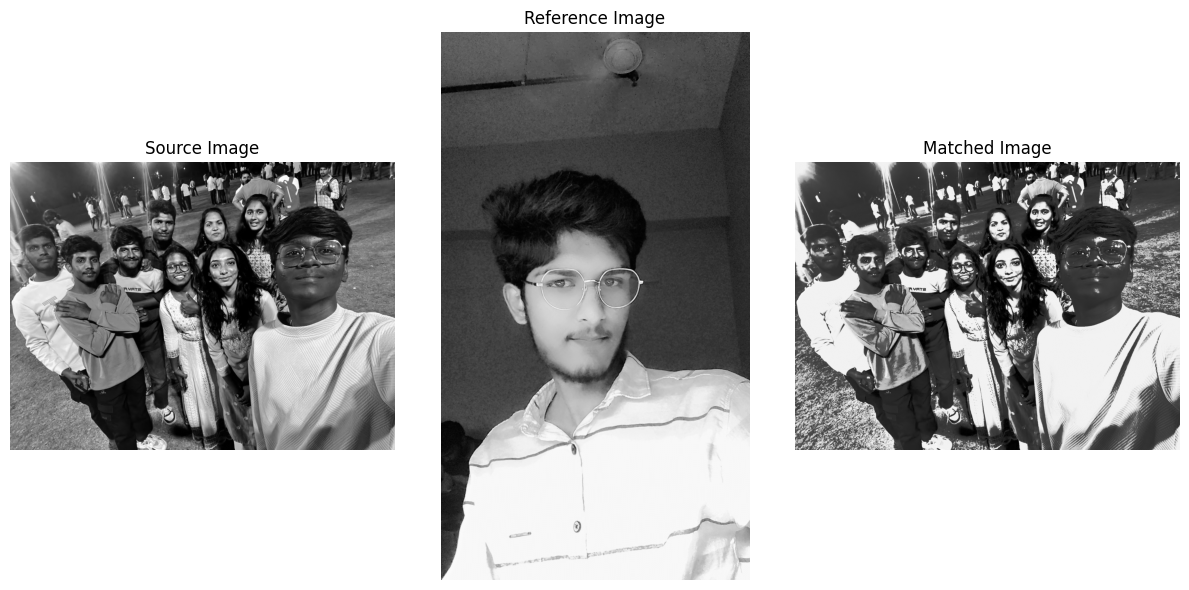

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = '/content/748.jpeg'

image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if image is None:
    print("Error: Image not found!")
else:
    print("Image loaded successfully.")
    print("Image size:", image.shape)
    histogram = cv2.calcHist([image], [0], None, [256], [0, 256])

plt.figure(figsize=(8, 6))
plt.title('Original Image Histogram')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.plot(histogram)
plt.xlim([0, 256])
plt.grid(True)
plt.show()

equalized_image = cv2.equalizeHist(image)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(image, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Equalized Image')
plt.imshow(equalized_image, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

equalized_histogram = cv2.calcHist(
    [equalized_image], [0], None, [256], [0, 256]
)

plt.figure(figsize=(8, 6))
plt.title('Equalized Image Histogram')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.plot(equalized_histogram)
plt.xlim([0, 256])
plt.grid(True)
plt.show()

source_path = '/content/hello_21.jpg'
reference_path = '/content/hello_26.jpg'

source_image = cv2.imread(source_path, cv2.IMREAD_GRAYSCALE)
reference_image = cv2.imread(reference_path, cv2.IMREAD_GRAYSCALE)

if source_image is None:
    print("Error: Source image not found!")

elif reference_image is None:
    print("Error: Reference image not found!")

else:

    # Calculate histograms
    source_hist = cv2.calcHist(
        [source_image], [0], None, [256], [0, 256]
    )

    reference_hist = cv2.calcHist(
        [reference_image], [0], None, [256], [0, 256]
    )


    # Normalize histograms
    source_hist = source_hist / source_hist.sum()
    reference_hist = reference_hist / reference_hist.sum()


    # Calculate CDF
    source_cdf = source_hist.cumsum()
    reference_cdf = reference_hist.cumsum()


    mapping = np.interp(
        source_cdf,
        reference_cdf,
        np.arange(256)
    )


    matched_image = mapping[source_image]

    # Convert to uint8
    matched_image = matched_image.astype(np.uint8)

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 3, 1)
    plt.title('Source Image')
    plt.imshow(source_image, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title('Reference Image')
    plt.imshow(reference_image, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title('Matched Image')
    plt.imshow(matched_image, cmap='gray')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

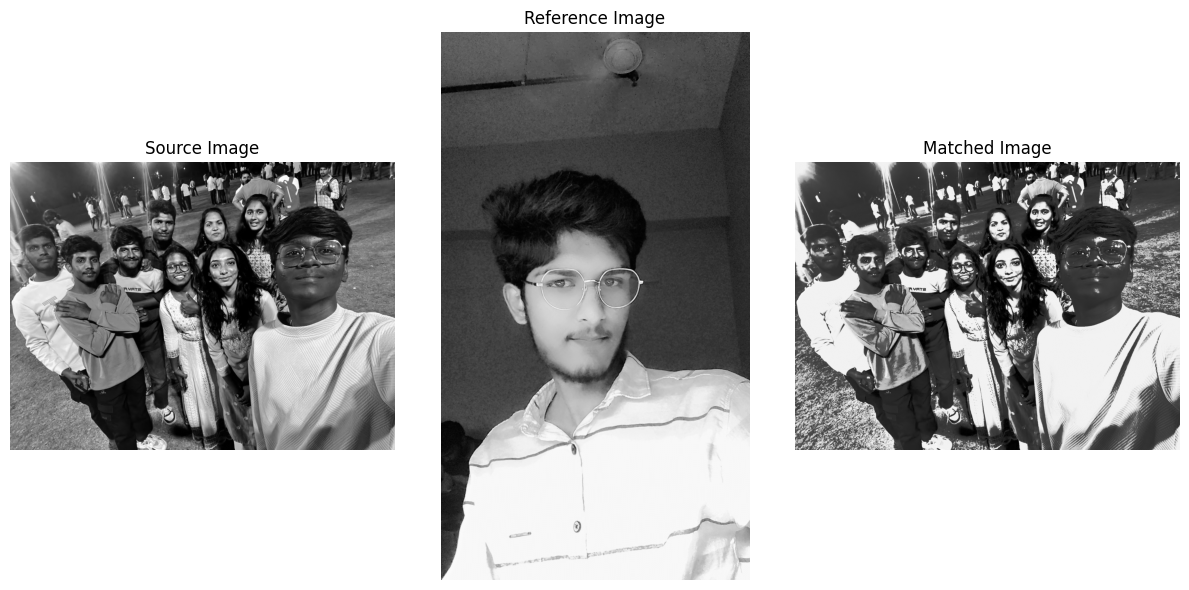

In [11]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Load the source and reference images
source_path = '/content/hello_21.jpg'
reference_path = '/content/hello_26.jpg'

source_image = cv2.imread(source_path, cv2.IMREAD_GRAYSCALE)
reference_image = cv2.imread(reference_path, cv2.IMREAD_GRAYSCALE)

# Calculate histograms for the source and reference images
source_hist = cv2.calcHist([source_image], [0], None, [256], [0, 256])
reference_hist = cv2.calcHist([reference_image], [0], None, [256], [0, 256])

# Normalize histograms to have sum equal to 1
source_hist /= source_hist.sum()
reference_hist /= reference_hist.sum()

# Calculate cumulative distribution functions (CDF) for histograms
source_cdf = source_hist.cumsum()
reference_cdf = reference_hist.cumsum()

# Perform histogram matching by mapping source CDF to reference CDF
mapping = np.interp(source_cdf, reference_cdf, range(256))
matched_image = mapping[source_image]

# Convert to uint8 data type
matched_image = matched_image.astype(np.uint8)

# Display the images using Matplotlib
plt.figure(figsize=(12, 6))
plt.subplot(131)
plt.title('Source Image')
plt.imshow(source_image, cmap='gray')
plt.axis('off')

plt.subplot(132)
plt.title('Reference Image')
plt.imshow(reference_image, cmap='gray')
plt.axis('off')

plt.subplot(133)
plt.title('Matched Image')
plt.imshow(matched_image, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()